<a href="https://colab.research.google.com/github/SaidCondoriRomero/SiS420_Inteligencia_Artificial/blob/main/Laboratorios/Laboratorio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Condori Romero Said - Ing. Sistemas
## Laboratorio 1
# Origen del Dataset (Smart Grid Stability)
Página de obtención
El dataset fue descargado desde la plataforma Kaggle en la siguiente URL: https://www.kaggle.com/datasets/pcbreviglieri/smart-grid-stability

 Fueron generados a través de simulaciones de modelos de control descentralizado (DSGC) para redes eléctricas, un trabajo de investigación llevado a cabo originalmente por científicos del Karlsruhe Institute of Technology (KIT) en Alemania.

#Objetivo
 Es estudiar el Dataset si es posible predecir la estabilidad de una red eléctrica inteligente a partir de sus parámetros operativos, sin necesidad de resolver las ecuaciones diferenciales completas. Esto nos permite saber en milisegundos si la red está en peligro de apagarse, sin perder tiempo resolviendo ecuaciones físicas complejas.

## Dimensiones del Dataset
Cantidad de Ejemplos ($m = 60000$)
Cantidad de Características ($n = 14$):


In [ ]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Manejo de datos tabulares
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## Carga de Datos y Exploración Inicial

### Preprocesamiento

El dataset tiene **14 columnas**: 12 numéricas + `stab` (numérica) + `stabf` (texto: `'stable'`/`'unstable'`).  


4 columnas de Tiempo de reacción ($\tau$): tau1, tau2, tau3, tau4. Segundos ($s$).

4 columnas de Equilibrio de potencia ($p$): p1, p2, p3, p4.  Segundos a la inversa al cuadrado ($s^{-2}$ o $1/s^2$). -> ACELERACIÓN de energía

4 columnas de Coeficiente de elasticidad ($g$): g1, g2, g3, g4.Segundos a la inversa ($s^{-1}$ ). -> VELOCIDAD de adaptación

1 columna stab: Es el valor numérico exacto de la estabilidad. (Esta es la número 13, la que usaste como tu vector $y$).

1 columna stabf: Es el valor en texto ('stable' o 'unstable'). (Esta es la número 14, la que eliminaste  porque la Regresión Lineal solo entiende números, no palabras).

In [ ]:
# ── Opción A: leer desde Google Drive ─────────────────────────────────────────
ruta = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/smart_grid_stability_augmented.csv'

# Cargar con pandas (maneja encabezados y columnas mixtas sin configuración extra)
df = pd.read_csv(ruta)

print('Dimensiones del dataset:', df.shape)
print('Columnas:', list(df.columns))
print()
print(df.head(10))

Dimensiones del dataset: (60000, 14)
Columnas: ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4', 'stab', 'stabf']

       tau1      tau2      tau3      tau4        p1        p2        p3  \
0  2.959060  3.079885  8.381025  9.780754  3.763085 -0.782604 -1.257395   
1  9.304097  4.902524  3.047541  1.369357  5.067812 -1.940058 -1.872742   
2  8.971707  8.848428  3.046479  1.214518  3.405158 -1.207456 -1.277210   
3  0.716415  7.669600  4.486641  2.340563  3.963791 -1.027473 -1.938944   
4  3.134112  7.608772  4.943759  9.857573  3.525811 -1.125531 -1.845975   
5  6.999209  9.109247  3.784066  4.267788  4.429669 -1.857139 -0.670397   
6  6.710166  3.765204  6.929314  8.818562  2.397419 -0.614590 -1.208826   
7  6.953512  1.379125  5.719400  7.870307  3.224495 -0.748998 -1.186517   
8  4.689852  4.007747  1.478573  3.733787  4.041300 -1.410344 -1.238204   
9  9.841496  1.413822  9.769856  7.641616  4.727595 -1.991363 -0.857637   

         p4        g1       


Para las operaciones de álgebra lineal se usa `np.loadtxt` con dos parámetros clave:
- **`skiprows=1`** → omite la primera fila (encabezado con nombres de columnas)
- **`usecols=range(13)`** → lee solo las 13 columnas numéricas, descartando `stabf`

### Preprocesamiento — Paso 3: Separación X / y

Se separan las **12 características** de la **variable objetivo**:
- `X = data[:, :12]` → columnas 0 a 11: `tau1`–`tau4`, `p1`–`p4`, `g1`–`g4`
- `y = data[:, 12]`  → columna 12: `stab` (lo que queremos predecir)

In [ ]:
# Normalización de caracteristicas.-
# Cargar datos
# data = np.loadtxt(os.path.join('Datasets', 'smart_grid_stability_augmented.csv'), delimiter=',', skiprows=1, usecols=range(13))
df = pd.read_csv(ruta)
df = df.drop('stabf', axis=1)  # Quitamos la columna de texto
data = df.values               # Convertimos a matriz numpy

X = data[:, :12] # Tomamos las 12 características
y = data[:, 12] # Tomamos la columna 12 (estabilidad)
m = y.size
print('Numero de ejemplos de entrenamiento (m):', m)
print('Numero de caracteristicas (n):', X.shape[1])

# Nombres de las caracteristicas para impresion
nombres = ['tau1','tau2','tau3','tau4','p1','p2','p3','p4','g1','g2','g3','g4']

# imprimir algunos puntos de datos
print('\n{:>6s}  '.format('') + '  '.join('{:>8s}'.format(n) for n in nombres) + '  {:>10s}'.format('stab'))
print('-' * 115)
for i in range(10):
    fila = '  '.join('{:8.4f}'.format(X[i, j]) for j in range(12))
    print('Ej {:>2d}:  '.format(i+1) + fila + '  {:10.6f}'.format(y[i]))

Numero de ejemplos de entrenamiento (m): 60000
Numero de caracteristicas (n): 12

            tau1      tau2      tau3      tau4        p1        p2        p3        p4        g1        g2        g3        g4        stab
-------------------------------------------------------------------------------------------------------------------
Ej  1:    2.9591    3.0799    8.3810    9.7808    3.7631   -0.7826   -1.2574   -1.7231    0.6505    0.8596    0.8874    0.9580    0.055347
Ej  2:    9.3041    4.9025    3.0475    1.3694    5.0678   -1.9401   -1.8727   -1.2550    0.4134    0.8624    0.5621    0.7818   -0.005957
Ej  3:    8.9717    8.8484    3.0465    1.2145    3.4052   -1.2075   -1.2772   -0.9205    0.1630    0.7667    0.8394    0.1099    0.003471
Ej  4:    0.7164    7.6696    4.4866    2.3406    3.9638   -1.0275   -1.9389   -0.9974    0.4462    0.9767    0.9294    0.3627    0.028871
Ej  5:    3.1341    7.6088    4.9438    9.8576    3.5258   -1.1255   -1.8460   -0.5543    0.7971    0.4554 

## Descenso por el Gradiente

### Función de Normalización de Características
Las 12 características tienen **escalas muy distintas**, lo que impediría la convergencia del gradiente.

Las variables `tau` (rango 0.5–10), `p` (rango −2 a +5) y `g` (rango 0.05–1) tienen escalas muy diferentes.
La normalización es **indispensable** para que el descenso por el gradiente converja correctamente:

$$x_{norm} = \frac{x - \mu}{\sigma}$$

In [ ]:
# Descenso por el gradiente.-

def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('\nMedia calculada:', mu)
print('\nDesviación estandar calculada:', sigma)
print(X_norm)

[[2.95906002 3.0798852  8.38102539 ... 0.85957811 0.88744492 0.95803399]
 [9.30409723 4.90252411 3.04754073 ... 0.86241408 0.56213905 0.78175991]
 [8.97170691 8.84842842 3.04647875 ... 0.76668866 0.83944402 0.10985324]
 ...
 [2.36403419 8.77639096 2.84203025 ... 0.14928646 0.98650532 0.14598403]
 [9.63151069 2.75707093 3.9943976  ... 0.88911835 0.58755755 0.81839133]
 [6.53052662 4.34969522 6.7817899  ... 0.37876093 0.50544105 0.94263083]]

Media calculada: [ 5.24999993  5.25000054  5.25000054  5.25000054  3.74999996 -1.24999999
 -1.24999999 -1.24999999  0.52499979  0.52500023  0.52500023  0.52500023]

Desviación estandar calculada: [2.74241124 2.74241409 2.74241409 2.74241409 0.7521225  0.43301333
 0.43301333 0.43301333 0.27424182 0.27424114 0.27424114 0.27424114]
[[-0.83537431 -0.7913157   1.1417039  ...  1.22001344  1.32162771
   1.57902551]
 [ 1.47829663 -0.12670458 -0.80310987 ...  1.23035459  0.13542396
   0.93625515]
 [ 1.35709296  1.31213878 -0.80349711 ...  0.88129894  1.14659

In [ ]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [ ]:
print(X)

[[ 1.         -0.83537431 -0.7913157  ...  1.22001344  1.32162771
   1.57902551]
 [ 1.          1.47829663 -0.12670458 ...  1.23035459  0.13542396
   0.93625515]
 [ 1.          1.35709296  1.31213878 ...  0.88129894  1.14659597
  -1.51380272]
 ...
 [ 1.         -1.05234609  1.28587088 ... -1.37001243  1.68284412
  -1.38205448]
 [ 1.          1.59768553 -0.90902742 ...  1.32772973  0.22811064
   1.06982889]
 [ 1.          0.4669346  -0.32828934 ... -0.53325077 -0.07132111
   1.52285905]]


### Función de Costo

La función de costo $J(\theta)$ mide el **error cuadrático medio** entre las predicciones del modelo y los valores reales de `stab`:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

In [ ]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    J = 0

    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

### Algoritmo de Descenso por el Gradiente

$$\theta := \theta - \frac{\alpha}{m} X^T (X\theta - y)$$

Con 12 características, el vector $\theta$ tendrá **13 parámetros** (incluyendo el sesgo $\theta_0$).

In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será actualizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

### Ejecución y Resultados del Descenso por el Gradiente

theta calculado por el descenso por el gradiente: [ 1.57258312e-02  9.93737800e-03  1.02806476e-02  1.02806476e-02
  1.02806476e-02 -8.40778101e-07  4.86796505e-07  4.86796505e-07
  4.86796505e-07  1.03595188e-02  1.07293398e-02  1.07293398e-02
  1.07293398e-02]
El valor de estabilidad predecido para la red de prueba (usando el descenso por el gradiente): 0.035333
Estado: INESTABLE (stab > 0)


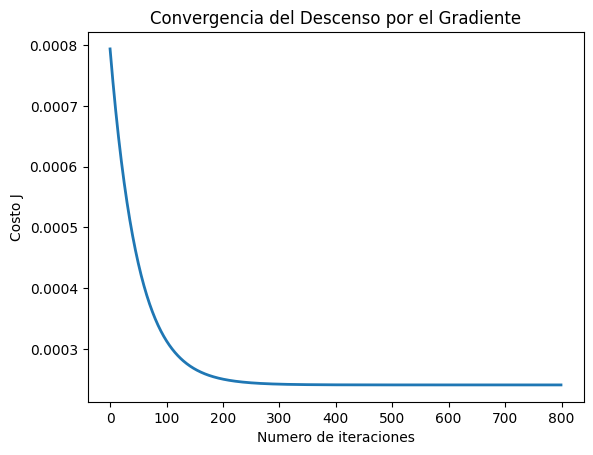

In [ ]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01
num_iters = 800


theta = np.zeros(13)
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)


pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por el Gradiente')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# Estimar stab para: tau=[3,4,6,8], p=[4,-1,-1.5,-1.5], g=[0.7,0.8,0.6,0.5]
X_array = [1, 3.0, 4.0, 6.0, 8.0, 4.0, -1.0, -1.5, -1.5, 0.7, 0.8, 0.6, 0.5]
X_array[1:13] = (X_array[1:13] - mu) / sigma
stab_pred = np.dot(X_array, theta)

print('El valor de estabilidad predecido para la red de prueba (usando el descenso por el gradiente): {:.6f}'.format(stab_pred))
print('Estado: {}'.format('INESTABLE (stab > 0)' if stab_pred > 0 else 'ESTABLE (stab <= 0)'))

### Predicción para una Configuración de Red Personalizada

In [ ]:
# 1. Definimos un nuevo array con 1 (intersección) y 12 valores de prueba (características de la red)
X_array = [1, 9.304, 4.902, 3.047, 1.369, 5.067, -1.940, -1.872, -1.255, 0.413, 0.862, 0.562, 0.781]
# Normalizar con el mismo mu y sigma calculados durante el entrenamiento
X_array[1:13] = (X_array[1:13] - mu) / sigma

In [ ]:
# Calcular la predicción
stab_pred = np.dot(X_array, theta)

print('La estabilidad predecida para esta red eléctrica (usando el descenso por el gradiente): {:.6f}'.format(stab_pred))
print('Estado: {}'.format('INESTABLE (stab > 0)' if stab_pred > 0 else 'ESTABLE (stab <= 0)'))

La estabilidad predecida para esta red eléctrica (usando el descenso por el gradiente): 0.026718
Estado: INESTABLE (stab > 0)


---
## Ecuación de la Normal

$$\theta = (X^T X)^{-1} X^T y$$

> Con $n=12$ características la inversión de $(X^TX)^{-1}$ es perfectamente viable.

In [ ]:
# Cargar datos
ruta = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/smart_grid_stability_augmented.csv'
X = data[:, :12]
y = data[:, 12]
m = y.size

print("Cantidad de ejemplos (m):", m)


X = np.concatenate([np.ones((m, 1)), X], axis=1)
print("Forma final de la matriz X:", X.shape)

Cantidad de ejemplos (m): 60000
Forma final de la matriz X: (60000, 13)


In [ ]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)

    return theta

In [ ]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y)

# Muestra los resultados obtenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal:')
print(str(theta))

# Estimar stab para: tau=[3,4,6,8], p=[4,-1,-1.5,-1.5], g=[0.7,0.8,0.6,0.5]
X_array = [1, 2.95, 3.07, 8.38, 9.78, 3.76, -0.78, -1.25, -1.72, 0.65, 0.85, 0.88, 0.95]
stab_pred = np.dot(X_array, theta)

print('\nPrediccion de estabilidad para el nodo de prueba (usando la ecuación de la normal):')
print('  stab predecido = {:.6f}'.format(stab_pred))
print('  Estado: {}'.format('INESTABLE (stab > 0)' if stab_pred > 0 else 'ESTABLE (stab <= 0)'))

Theta calculado a partir de la ecuación de la normal:
[-0.10594491  0.00276475  0.00293478  0.00290614  0.0029126   1.62445643
  1.64793056  1.60247139  1.60255163  0.03778661  0.03913542  0.03913542
  0.03913542]

Prediccion de estabilidad para el nodo de prueba (usando la ecuación de la normal):
  stab predecido = 0.156596
  Estado: INESTABLE (stab > 0)
